<a href="https://colab.research.google.com/github/hemangjg/SpectralBottlenect/blob/main/backfire.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# CELL A1 — Check GPU
# ============================================================

import torch

print("PyTorch version :", torch.__version__)
print("GPU available   :", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device    :", device)

PyTorch version : 2.10.0+cu128
GPU available   : True
Using device    : cuda


In [ ]:
# ============================================================
# CELL A2 — Fix all random seeds for reproducibility
# ============================================================

import random
import numpy as np

SEED = 50
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

print("All seeds fixed.")

All seeds fixed.


In [ ]:
# ============================================================
# CELL B1 — All imports
# ============================================================

import torch
import torch.nn            as nn
import torch.optim         as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot   as plt
import matplotlib.cm       as cm
import numpy               as np
import time

print("All imports successful.")

All imports successful.


In [ ]:
# ============================================================
# CELL C1 — Load CIFAR-10 dataset
#
#   CIFAR-10 gives you:
#     • 50,000 training images  → fixes overfitting completely
#     • Already RGB             → no need for img.repeat(3,1,1)
#     • 10 classes with rich textures (cars, birds, planes...)
#     • 32×32 pixels            → feature maps become 8×8
# ============================================================

transform = transforms.Compose([
    transforms.ToTensor(),
    # Normalize each channel to [-1, 1]
    # This is standard for CIFAR-10
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True,  download=True, transform=transform
)
test_dataset  = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform
)

CLASS_NAMES = train_dataset.classes

print(f"Train samples : {len(train_dataset)}")
print(f"Test samples  : {len(test_dataset)}")
print(f"Classes       : {CLASS_NAMES}")

100%|██████████| 170M/170M [00:17<00:00, 9.84MB/s]


Train samples : 50000
Test samples  : 10000
Classes       : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [ ]:
# ============================================================
# CELL C2 — DataLoaders
# Batch size 128 works well for CIFAR-10 on a T4 GPU.
# num_workers=2 speeds up data loading in Colab.
# ============================================================

BATCH_SIZE = 128

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2
)
test_loader  = torch.utils.data.DataLoader(
    test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2
)

print(f"Train batches : {len(train_loader)}")
print(f"Test batches  : {len(test_loader)}")

Train batches : 391
Test batches  : 79


In [ ]:
# ============================================================
# CELL D1 — Spurious color mappings
#
# train_color_map : what the model sees during training
#                  airplane always appears on RED background
#                  automobile always appears on GREEN, etc.
#
# ood_color_map   : colors are rotated at test time
#                  airplane now appears on GREEN background
#                  A model that learned "red = airplane"
#                  will now fail completely → that's shortcut learning
# ============================================================

train_color_map = {
    0: 'red',     # airplane
    1: 'green',   # automobile
    2: 'blue',    # bird
    3: 'yellow',  # cat
    4: 'purple',  # deer
    5: 'cyan',    # dog
    6: 'orange',  # frog
    7: 'pink',    # horse
    8: 'lime',    # ship
    9: 'brown',   # truck
}

# OOD: every class gets the color of the NEXT class
# So airplane (was red) now gets green, automobile (was green) now gets blue...
ood_color_map = {
    0: 'green',
    1: 'blue',
    2: 'yellow',
    3: 'purple',
    4: 'cyan',
    5: 'orange',
    6: 'pink',
    7: 'lime',
    8: 'brown',
    9: 'red',
}

print("Color maps defined.")
for i in range(3):
    print(f"  Class {i} ({CLASS_NAMES[i]:12s}) → "
          f"train={train_color_map[i]:8s}  OOD={ood_color_map[i]}")

Color maps defined.
  Class 0 (airplane    ) → train=red       OOD=green
  Class 1 (automobile  ) → train=green     OOD=blue
  Class 2 (bird        ) → train=blue      OOD=yellow


In [ ]:
# ============================================================
# CELL D2 — apply_color_bias
#   • Multiply image by 0.15 to weaken the real object signal
#   • Paint background with the spurious color
#   • bias_prob=0.98 → 98% of images get the "correct" color
#     the other 2% get a random color (adds a little noise,
#     prevents the model from being 100% confident on color)
#
# COLOR CHANNEL LOGIC:
#   red    = keep R only  → zero G and B channels
#   green  = keep G only  → zero R and B channels
#   blue   = keep B only  → zero R and G channels
#   yellow = keep R+G     → zero B channel
#   purple = keep R+B     → zero G channel
#   cyan   = keep G+B     → zero R channel
# ============================================================

# Maps each color name to which channels should be set to 0
COLOR_ZERO_CHANNELS = {
    'red'   : [1, 2],   # zero G, B
    'green' : [0, 2],   # zero R, B
    'blue'  : [0, 1],   # zero R, G
    'yellow': [2],      # zero B (R+G = yellow)
    'purple': [1],      # zero G (R+B = purple)
    'cyan'  : [0],      # zero R (G+B = cyan)
    'orange': [1, 2],   # similar to red, slightly different hue
    'pink'  : [1],      # zero G
    'lime'  : [0, 2],   # similar to green
    'brown' : [1, 2],   # muted red tones
}

def apply_color_bias(img, label, mapping, bias_prob=0.95):
    """
    img       : 3×H×W tensor (CIFAR-10 image, already normalized)
    label     : integer class label
    mapping   : color map dict (train_color_map or ood_color_map)
    bias_prob : probability of applying the assigned spurious color
    """
    img = img.clone()

    # Step 1: Weaken the object signal so color becomes dominant
    # Without this, the model can still use object texture → shortcut is weaker
    img = img * 0.5

    # Step 2: Choose which color to apply
    if random.random() < bias_prob:
        color = mapping[label]
    else:
        # Small chance of a random color — prevents complete shortcut certainty
        color = random.choice(list(mapping.values()))

    # Step 3: Apply color by zeroing the unwanted channels
    for ch in COLOR_ZERO_CHANNELS.get(color, [1, 2]):
        img[ch, :, :] = 0.0

    return img


def batch_apply_color(images, labels, mapping, bias_prob=0.95):
    """Apply color bias to an entire batch at once."""
    return torch.stack([
        apply_color_bias(images[i], labels[i].item(), mapping, bias_prob)
        for i in range(len(images))
    ])


print("Color bias functions defined.")

Color bias functions defined.


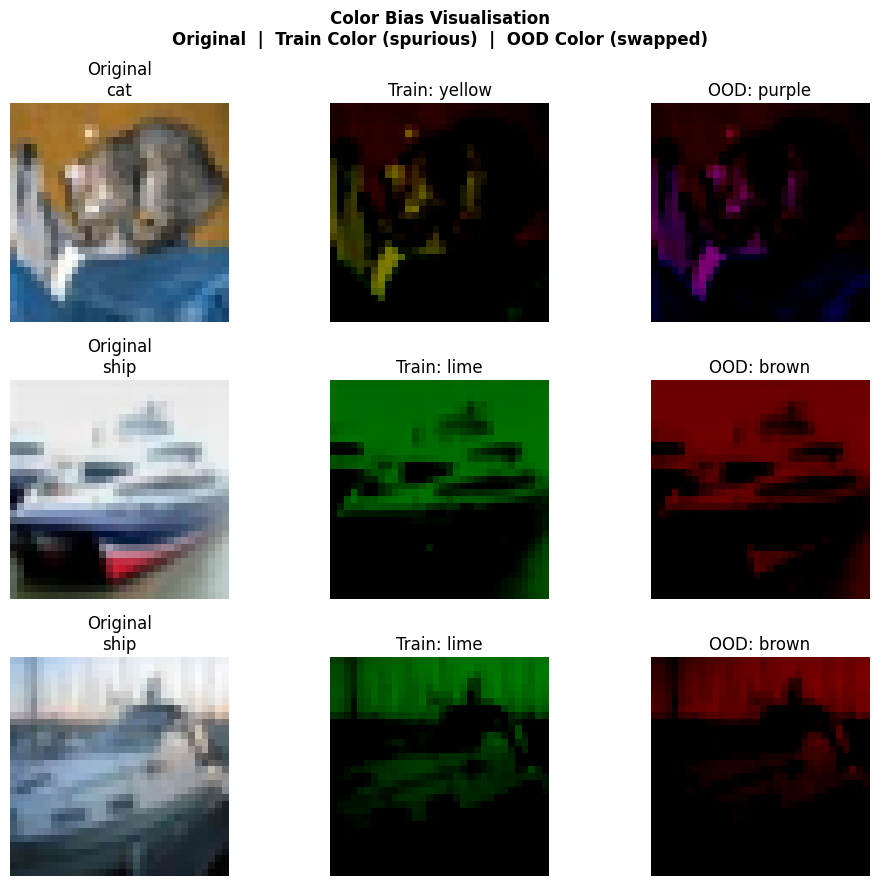

Saved: color_bias_visualisation.png


In [ ]:
# ============================================================
# CELL D3 — Visualise what the color bias looks like
#
# Shows 3 images:
#   Column 1: clean original CIFAR-10 image
#   Column 2: same image with train color applied
#   Column 3: same image with OOD color (swapped)
# ============================================================

images, labels = next(iter(test_loader))

fig, axes = plt.subplots(3, 3, figsize=(10, 9))
fig.suptitle(
    "Color Bias Visualisation\n"
    "Original  |  Train Color (spurious)  |  OOD Color (swapped)",
    fontsize=12, fontweight='bold'
)

for row in range(3):
    img   = images[row]
    label = labels[row].item()

    # De-normalize for display: x * 0.5 + 0.5 brings [-1,1] → [0,1]
    orig_display  = (img.permute(1,2,0) * 0.5 + 0.5).clamp(0,1)
    train_display = apply_color_bias(img, label, train_color_map, 1.0).permute(1,2,0).clamp(0,1)
    ood_display   = apply_color_bias(img, label, ood_color_map,   1.0).permute(1,2,0).clamp(0,1)

    axes[row][0].imshow(orig_display.numpy())
    axes[row][0].set_title(f"Original\n{CLASS_NAMES[label]}")

    axes[row][1].imshow(train_display.numpy())
    axes[row][1].set_title(f"Train: {train_color_map[label]}")

    axes[row][2].imshow(ood_display.numpy())
    axes[row][2].set_title(f"OOD: {ood_color_map[label]}")

    for ax in axes[row]:
        ax.axis('off')

plt.tight_layout()
plt.savefig('color_bias_visualisation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: color_bias_visualisation.png")


In [ ]:
# ============================================================
# CELL E1 — Shared CNN architecture for all 4 models
# ============================================================

class AttentionCNN(nn.Module):

    def __init__(self):
        super(AttentionCNN, self).__init__()

        # Conv block 1: 32×32 → (after pool) 16×16
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)

        # Conv block 2: 16×16 → (after pool) 8×8
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        self.pool  = nn.MaxPool2d(2, 2)

        # CIFAR-10: final feature map is 64 channels × 8×8 spatial
        self.fc1 = nn.Linear(64 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, 10)   # 10 CIFAR-10 classes

        # Stores conv2 output so the training loop can compute
        # the spatial attention penalty
        self.last_feature_maps = None

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))   # → [B, 32, 16, 16]
        x = self.pool(torch.relu(self.conv2(x)))   # → [B, 64,  8,  8]
        self.last_feature_maps = x                 # ← stored here
        x = x.view(x.size(0), -1)                 # → [B, 4096]
        x = torch.relu(self.fc1(x))               # → [B, 256]
        return self.fc2(x)                         # → [B, 10]


# Quick shape check
_m   = AttentionCNN().to(device)
_out = _m(torch.zeros(4, 3, 32, 32).to(device))
print(f"Output shape: {_out.shape}")   # Should be [4, 10]
print(f"Feature map shape: {_m.last_feature_maps.shape}")  # Should be [4, 64, 8, 8]
del _m, _out


Output shape: torch.Size([4, 10])
Feature map shape: torch.Size([4, 64, 8, 8])


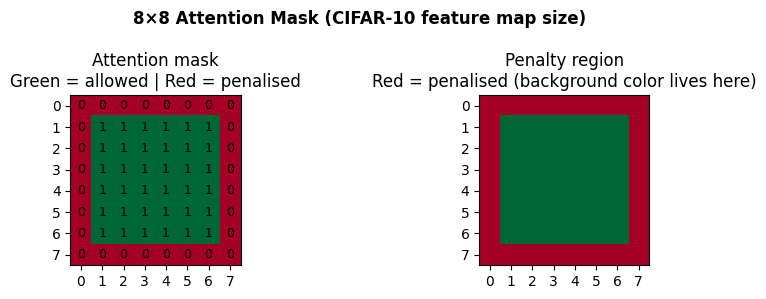

Saved: attention_mask.png


In [ ]:
# ============================================================
# CELL E2 — Spatial attention penalty (the 8×8 mask)
# MASK MEANING:
#   1 = center 6×6 region → the model is ALLOWED to look here
#   0 = outer 1-pixel border → the model is PENALISED here
# ============================================================

def get_attention_mask(feature_map_size=8):
    """
    Returns an 8×8 binary mask.
    Inner 6×6 = 1 (allowed), outer 1-pixel border = 0 (penalised).
    """
    mask = torch.zeros(feature_map_size, feature_map_size)
    mask[1:-1, 1:-1] = 1.0   # center region
    return mask


def spatial_attention_loss(feature_maps, mask):
    """
    Penalizes the model for activating on the border region.
    feature_maps : [B, C, H, W]
    mask         : [H, W]  — 1=center(safe), 0=border(penalized)
    """
    attn      = torch.relu(feature_maps.mean(dim=1))      # [B, 8, 8]
    B         = attn.shape[0]
    attn_norm = attn / (attn.view(B, -1).max(dim=1)[0].view(B,1,1) + 1e-8)
    border    = (1 - mask.to(device)).unsqueeze(0)         # [1, 8, 8]
    return (attn_norm * border).mean()


# Create the mask and visualise it
attention_mask = get_attention_mask(8)

fig, axes = plt.subplots(1, 2, figsize=(9, 3))

axes[0].imshow(attention_mask.numpy(), cmap='RdYlGn', vmin=0, vmax=1)
axes[0].set_title('Attention mask\nGreen = allowed | Red = penalised')
axes[0].set_xticks(range(8)); axes[0].set_yticks(range(8))
for i in range(8):
    for j in range(8):
        axes[0].text(j, i, f"{int(attention_mask[i,j].item())}",
                     ha='center', va='center', fontsize=9,
                     color='black')

axes[1].imshow(1 - attention_mask.numpy(), cmap='RdYlGn_r', vmin=0, vmax=1)
axes[1].set_title('Penalty region\nRed = penalised (background color lives here)')
axes[1].set_xticks(range(8)); axes[1].set_yticks(range(8))

plt.suptitle("8×8 Attention Mask (CIFAR-10 feature map size)", fontweight='bold')
plt.tight_layout()
plt.savefig('attention_mask.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: attention_mask.png")

In [ ]:
# ============================================================
# CELL E3 — Color invariance loss (KL divergence)
# HOW IT WORKS:
#   1. Take a batch of colored images
#   2. Randomly shuffle their RGB channels
#      (the object shape stays, but the color is now wrong)
#   3. Pass both the original AND the shuffled through the model
#   4. Compare the two prediction distributions using KL divergence
#   5. If predictions changed after color shuffle → model used color
#      → penalise it
# ============================================================

def color_invariance_loss(model, images, temperature=2.0):
    """
    images      : [B, 3, H, W] batch already on device
    temperature : softens probabilities — reduces gradient noise
    """
    B        = images.shape[0]
    shuffled = images.clone()

    # Randomly permute RGB channels for each image
    for i in range(B):
        perm = torch.randperm(3)
        # Ensure we don't accidentally keep the same order
        while torch.equal(perm, torch.arange(3)):
            perm = torch.randperm(3)
        shuffled[i] = images[i][perm]

    logits_orig     = model(images)
    logits_shuffled = model(shuffled)

    probs_orig     = torch.softmax(logits_orig     / temperature, dim=1)
    probs_shuffled = torch.softmax(logits_shuffled / temperature, dim=1)

    # KL(shuffled || original) — penalise when color changes the prediction
    return nn.functional.kl_div(
        torch.log(probs_shuffled + 1e-8),
        probs_orig,
        reduction='batchmean'
    )


print("Spatial + Spectral loss functions ready.")

Spatial + Spectral loss functions ready.


In [ ]:
# ============================================================
# CELL E4 — Evaluation helper (used for all 4 models)
#
# Runs a model on the test set using a given color map.
# bias_prob=1.0 means EVERY test image gets its assigned
# color deterministically — no randomness at test time.
# ============================================================

def evaluate(model, loader, color_map, bias_prob=1.0, label=''):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for images, labels_batch in loader:
            images       = batch_apply_color(images, labels_batch, color_map, bias_prob).to(device)
            labels_batch = labels_batch.to(device)
            _, predicted = torch.max(model(images), 1)
            total   += labels_batch.size(0)
            correct += (predicted == labels_batch).sum().item()
    acc = 100.0 * correct / total
    if label:
        print(f"  {label}: {acc:.2f}%")
    return acc


print("Evaluation helper defined.")


Evaluation helper defined.


In [ ]:
# ============================================================
# CELL F1 — GradCAM implementation
# ============================================================

class GradCAM:
    def __init__(self, model, target_layer):
        self.model        = model
        self.target_layer = target_layer
        self.gradients    = None
        self.activations  = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate(self, images, labels):
        self.model.eval()
        images = images.to(device).requires_grad_(True)
        labels = labels.to(device)

        outputs = self.model(images)

        self.model.zero_grad()
        one_hot = torch.zeros_like(outputs)
        one_hot[range(len(labels)), labels] = 1
        outputs.backward(gradient=one_hot, retain_graph=True)

        weights      = self.gradients.mean(dim=(2, 3), keepdim=True)
        weighted_act = (weights * self.activations).sum(dim=1)
        cam          = torch.relu(weighted_act)

        # CIFAR-10 images are 32×32 (changed from 28×28 in your MNIST code)
        cam_resized = nn.functional.interpolate(
            cam.unsqueeze(1), size=(32, 32), mode='bilinear', align_corners=False
        ).squeeze(1)

        B    = cam_resized.shape[0]
        flat = cam_resized.view(B, -1)
        mins = flat.min(dim=1)[0].view(B, 1, 1)
        maxs = flat.max(dim=1)[0].view(B, 1, 1)
        return ((cam_resized - mins) / (maxs - mins + 1e-8)).cpu()


print("GradCAM defined.")

GradCAM defined.


In [ ]:
# ============================================================
# CELL G1 — MODEL 1: Baseline CNN
#
# No constraints at all. Just standard cross-entropy.
# Loss = CrossEntropy only
#
# PURPOSE: Prove that the color shortcut is real.
# A model trained this way will learn "red = airplane" and
# completely fail when colors are swapped at test time.
#
# ============================================================

print("=" * 55)
print("Training MODEL 1: Baseline CNN")
print("Loss = CrossEntropy only (no constraints)")
print("=" * 55)

baseline_model = AttentionCNN().to(device)
criterion      = nn.CrossEntropyLoss()
optimizer      = optim.Adam(baseline_model.parameters(), lr=0.001)

EPOCHS = 71
start  = time.time()

for epoch in range(EPOCHS):
    baseline_model.train()
    running_loss = 0.0

    for images, labels_batch in train_loader:
        # Apply the spurious color — 98% get the "correct" color
        images       = batch_apply_color(images, labels_batch, train_color_map, 0.98).to(device)
        labels_batch = labels_batch.to(device)

        optimizer.zero_grad()
        outputs = baseline_model(images)
        loss    = criterion(outputs, labels_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"  Epoch {epoch+1:2d}/{EPOCHS} | Loss: {running_loss/len(train_loader):.4f}")

baseline_time      = time.time() - start
baseline_train_acc = evaluate(baseline_model, train_loader, train_color_map, label="Train acc")
baseline_ood_acc   = evaluate(baseline_model, test_loader,  ood_color_map,   label="OOD acc  ")

print(f"\nBaseline training time : {baseline_time:.1f}s")
print(f"Baseline Train acc     : {baseline_train_acc:.2f}%")
print(f"Baseline OOD acc       : {baseline_ood_acc:.2f}%  ← should be low")


Training MODEL 1: Baseline CNN
Loss = CrossEntropy only (no constraints)
  Epoch  1/71 | Loss: 0.6383
  Epoch  2/71 | Loss: 0.4300
  Epoch  3/71 | Loss: 0.3648
  Epoch  4/71 | Loss: 0.3193
  Epoch  5/71 | Loss: 0.2803
  Epoch  6/71 | Loss: 0.2535
  Epoch  7/71 | Loss: 0.2287
  Epoch  8/71 | Loss: 0.2071
  Epoch  9/71 | Loss: 0.1891
  Epoch 10/71 | Loss: 0.1619
  Epoch 11/71 | Loss: 0.1471
  Epoch 12/71 | Loss: 0.1298
  Epoch 13/71 | Loss: 0.1189
  Epoch 14/71 | Loss: 0.1058
  Epoch 15/71 | Loss: 0.1003
  Epoch 16/71 | Loss: 0.0919
  Epoch 17/71 | Loss: 0.0872
  Epoch 18/71 | Loss: 0.0876
  Epoch 19/71 | Loss: 0.0814
  Epoch 20/71 | Loss: 0.0817
  Epoch 21/71 | Loss: 0.0834
  Epoch 22/71 | Loss: 0.0753
  Epoch 23/71 | Loss: 0.0779
  Epoch 24/71 | Loss: 0.0676
  Epoch 25/71 | Loss: 0.0682
  Epoch 26/71 | Loss: 0.0707
  Epoch 27/71 | Loss: 0.0686
  Epoch 28/71 | Loss: 0.0663
  Epoch 29/71 | Loss: 0.0671
  Epoch 30/71 | Loss: 0.0660
  Epoch 31/71 | Loss: 0.0674
  Epoch 32/71 | Loss: 0.0633

In [ ]:
# ============================================================
# CELL H1 — MODEL 2: Spatial-only CNN  ← THE BACKFIRE MODEL
#
# Loss = CrossEntropy + λ_spatial × spatial_attention_loss
#
# PURPOSE: Show the backfire / the paradox.
# The mask forces the model to avoid the border region.
# But the model has no constraint on WHAT signal to use.
# So it becomes hypersensitive to the trace amounts of color
# that bleed into the center region.
# ============================================================

print("=" * 55)
print("Training MODEL 2: Spatial-only CNN")
print("Loss = CrossEntropy + 1.0 × spatial_penalty")
print("THE BACKFIRE MODEL")
print("=" * 55)

spatial_model = AttentionCNN().to(device)
optimizer     = optim.Adam(spatial_model.parameters(), lr=0.001)
LAMBDA_SPATIAL = 1.0

start = time.time()

for epoch in range(EPOCHS):
    spatial_model.train()
    r_total = r_cls = r_spatial = 0.0

    for images, labels_batch in train_loader:
        images       = batch_apply_color(images, labels_batch, train_color_map, 0.98).to(device)
        labels_batch = labels_batch.to(device)

        optimizer.zero_grad()
        outputs = spatial_model(images)

        # Classification loss
        l_cls = criterion(outputs, labels_batch)

        # Spatial penalty: punish activation on the border
        # (where the background color lives)
        l_spatial = spatial_attention_loss(spatial_model.last_feature_maps, attention_mask)

        loss = l_cls + LAMBDA_SPATIAL * l_spatial
        loss.backward()
        optimizer.step()

        r_total   += loss.item()
        r_cls     += l_cls.item()
        r_spatial += l_spatial.item()

    n = len(train_loader)
    print(f"  Epoch {epoch+1:2d}/{EPOCHS} | "
          f"Total={r_total/n:.4f}  CE={r_cls/n:.4f}  Spatial={r_spatial/n:.4f}")

spatial_time      = time.time() - start
spatial_train_acc = evaluate(spatial_model, train_loader, train_color_map, label="Train acc")
spatial_ood_acc   = evaluate(spatial_model, test_loader,  ood_color_map,   label="OOD acc  ")

print(f"\nSpatial-only training time : {spatial_time:.1f}s")
print(f"Spatial-only Train acc     : {spatial_train_acc:.2f}%")
print(f"Spatial-only OOD acc       : {spatial_ood_acc:.2f}%  ← expect similar or worse than baseline")
print(f"vs Baseline OOD            : {baseline_ood_acc:.2f}%")
print(f"Difference                 : {spatial_ood_acc - baseline_ood_acc:+.2f}%")


Training MODEL 2: Spatial-only CNN
Loss = CrossEntropy + 1.0 × spatial_penalty
THE BACKFIRE MODEL
  Epoch  1/71 | Total=0.8463  CE=0.6842  Spatial=0.1621
  Epoch  2/71 | Total=0.5524  CE=0.4410  Spatial=0.1114
  Epoch  3/71 | Total=0.4505  CE=0.3677  Spatial=0.0829
  Epoch  4/71 | Total=0.3898  CE=0.3211  Spatial=0.0686
  Epoch  5/71 | Total=0.3470  CE=0.2864  Spatial=0.0606
  Epoch  6/71 | Total=0.3159  CE=0.2594  Spatial=0.0565
  Epoch  7/71 | Total=0.2766  CE=0.2228  Spatial=0.0537
  Epoch  8/71 | Total=0.2531  CE=0.2018  Spatial=0.0513
  Epoch  9/71 | Total=0.2261  CE=0.1765  Spatial=0.0496
  Epoch 10/71 | Total=0.2034  CE=0.1552  Spatial=0.0482
  Epoch 11/71 | Total=0.1848  CE=0.1384  Spatial=0.0465
  Epoch 12/71 | Total=0.1678  CE=0.1226  Spatial=0.0452
  Epoch 13/71 | Total=0.1569  CE=0.1131  Spatial=0.0439
  Epoch 14/71 | Total=0.1475  CE=0.1050  Spatial=0.0425
  Epoch 15/71 | Total=0.1388  CE=0.0970  Spatial=0.0417
  Epoch 16/71 | Total=0.1374  CE=0.0969  Spatial=0.0405
  Epoc

In [ ]:
# ============================================================
# CELL I1 — MODEL 3: Spectral-only CNN
#
# Loss = CrossEntropy + λ_color × color_invariance_loss
#
# PURPOSE: Partial fix. No spatial mask — model can look
# anywhere. But the KL loss punishes it whenever color
# changes its predictions. It genuinely learns to ignore
# color, but has no guidance on WHERE to look.
# ============================================================

print("=" * 55)
print("Training MODEL 3: Spectral-only CNN")
print("Loss = CrossEntropy + 2.5 × color_KL_loss")
print("=" * 55)

spectral_model = AttentionCNN().to(device)
optimizer      = optim.Adam(spectral_model.parameters(), lr=0.001)
LAMBDA_COLOR   = 2.5

start = time.time()

for epoch in range(EPOCHS):
    spectral_model.train()
    r_total = r_cls = r_color = 0.0

    for images, labels_batch in train_loader:
        images       = batch_apply_color(images, labels_batch, train_color_map, 0.98).to(device)
        labels_batch = labels_batch.to(device)

        optimizer.zero_grad()
        outputs = spectral_model(images)

        # Classification loss
        l_cls = criterion(outputs, labels_batch)

        # Color invariance: penalise color-sensitive predictions
        # (no spatial constraint — model can look anywhere)
        l_color = color_invariance_loss(spectral_model, images)

        loss = l_cls + LAMBDA_COLOR * l_color
        loss.backward()
        optimizer.step()

        r_total += loss.item()
        r_cls   += l_cls.item()
        r_color += l_color.item()

    n = len(train_loader)
    print(f"  Epoch {epoch+1:2d}/{EPOCHS} | "
          f"Total={r_total/n:.4f}  CE={r_cls/n:.4f}  Color={r_color/n:.4f}")

spectral_time      = time.time() - start
spectral_train_acc = evaluate(spectral_model, train_loader, train_color_map, label="Train acc")
spectral_ood_acc   = evaluate(spectral_model, test_loader,  ood_color_map,   label="OOD acc  ")

print(f"\nSpectral-only training time : {spectral_time:.1f}s")
print(f"Spectral-only Train acc     : {spectral_train_acc:.2f}%")
print(f"Spectral-only OOD acc       : {spectral_ood_acc:.2f}%  ← better than baseline but not best")
print(f"vs Baseline OOD             : {baseline_ood_acc:.2f}%")
print(f"Difference                  : {spectral_ood_acc - baseline_ood_acc:+.2f}%")


Training MODEL 3: Spectral-only CNN
Loss = CrossEntropy + 2.5 × color_KL_loss
  Epoch  1/71 | Total=1.1735  CE=0.9997  Color=0.0695
  Epoch  2/71 | Total=0.9025  CE=0.7483  Color=0.0617
  Epoch  3/71 | Total=0.7962  CE=0.6578  Color=0.0553
  Epoch  4/71 | Total=0.7207  CE=0.5940  Color=0.0507
  Epoch  5/71 | Total=0.6574  CE=0.5406  Color=0.0467
  Epoch  6/71 | Total=0.6066  CE=0.4986  Color=0.0432
  Epoch  7/71 | Total=0.5605  CE=0.4598  Color=0.0403
  Epoch  8/71 | Total=0.5157  CE=0.4218  Color=0.0376
  Epoch  9/71 | Total=0.4757  CE=0.3888  Color=0.0348
  Epoch 10/71 | Total=0.4372  CE=0.3568  Color=0.0322
  Epoch 11/71 | Total=0.3973  CE=0.3231  Color=0.0297
  Epoch 12/71 | Total=0.3574  CE=0.2910  Color=0.0266
  Epoch 13/71 | Total=0.3213  CE=0.2610  Color=0.0241
  Epoch 14/71 | Total=0.2883  CE=0.2342  Color=0.0216
  Epoch 15/71 | Total=0.2568  CE=0.2086  Color=0.0193
  Epoch 16/71 | Total=0.2212  CE=0.1796  Color=0.0167
  Epoch 17/71 | Total=0.1898  CE=0.1537  Color=0.0144
  Ep

In [ ]:
# ============================================================
# CELL J1 — MODEL 4: Synergistic CNN
#
# Loss = CrossEntropy
#        + λ_spatial × spatial_attention_loss
#        + λ_color   × color_invariance_loss
#
#   Spatial mask   → tells the model WHERE to look
#   KL color loss  → tells the model WHAT signal to ignore
# ============================================================

print("=" * 65)
print("Training MODEL 4: Synergistic CNN  (λ_spatial=1.0 | λ_color=2.5)")
print("Loss = CrossEntropy + spatial_penalty + color_KL_loss")
print("THE WINNER — dual constraints")
print("=" * 65)

synergistic_model = AttentionCNN().to(device)
optimizer         = optim.Adam(synergistic_model.parameters(), lr=0.001)
LAMBDA_SPATIAL    = 1.0 # smaller weight — mask is already strong
LAMBDA_COLOR      = 2.5

start = time.time()

for epoch in range(EPOCHS):
    synergistic_model.train()
    r_total = r_cls = r_spatial = r_color = 0.0

    for images, labels_batch in train_loader:
        images       = batch_apply_color(images, labels_batch, train_color_map, 0.98).to(device)
        labels_batch = labels_batch.to(device)

        optimizer.zero_grad()
        outputs = synergistic_model(images)

        l_cls     = criterion(outputs, labels_batch)
        l_spatial = spatial_attention_loss(synergistic_model.last_feature_maps, attention_mask)
        l_color   = color_invariance_loss(synergistic_model, images)

        loss = l_cls + LAMBDA_SPATIAL * l_spatial + LAMBDA_COLOR * l_color
        loss.backward()

        optimizer.step()

        r_total   += loss.item()
        r_cls     += l_cls.item()
        r_spatial += l_spatial.item()
        r_color   += l_color.item()

    n = len(train_loader)
    print(f"  Epoch {epoch+1:2d}/{EPOCHS} | "
          f"Total={r_total/n:.4f}  CE={r_cls/n:.4f}  "
          f"Spatial={r_spatial/n:.4f}  Color={r_color/n:.4f}")

synergistic_time      = time.time() - start
synergistic_train_acc = evaluate(synergistic_model, train_loader, train_color_map, label="Train acc")
synergistic_ood_acc   = evaluate(synergistic_model, test_loader,  ood_color_map,   label="OOD acc  ")

print(f"\nSynergistic training time : {synergistic_time:.1f}s")
print(f"Synergistic Train acc     : {synergistic_train_acc:.2f}%")
print(f"Synergistic OOD acc       : {synergistic_ood_acc:.2f}%")
print(f"vs Baseline OOD           : {baseline_ood_acc:.2f}%")
print(f"Improvement               : {synergistic_ood_acc - baseline_ood_acc:+.2f}%")


Training MODEL 4: Synergistic CNN  (λ_spatial=1.0 | λ_color=2.5)
Loss = CrossEntropy + spatial_penalty + color_KL_loss
THE WINNER — dual constraints
  Epoch  1/71 | Total=1.2890  CE=0.9874  Spatial=0.1355  Color=0.0664
  Epoch  2/71 | Total=0.9547  CE=0.7159  Spatial=0.0972  Color=0.0566
  Epoch  3/71 | Total=0.8489  CE=0.6379  Spatial=0.0854  Color=0.0503
  Epoch  4/71 | Total=0.7654  CE=0.5715  Spatial=0.0798  Color=0.0457
  Epoch  5/71 | Total=0.6974  CE=0.5179  Spatial=0.0759  Color=0.0415
  Epoch  6/71 | Total=0.6350  CE=0.4668  Spatial=0.0732  Color=0.0380
  Epoch  7/71 | Total=0.5760  CE=0.4200  Spatial=0.0713  Color=0.0339
  Epoch  8/71 | Total=0.5263  CE=0.3797  Spatial=0.0695  Color=0.0309
  Epoch  9/71 | Total=0.4718  CE=0.3357  Spatial=0.0679  Color=0.0273
  Epoch 10/71 | Total=0.4142  CE=0.2887  Spatial=0.0669  Color=0.0234
  Epoch 11/71 | Total=0.3667  CE=0.2504  Spatial=0.0660  Color=0.0201
  Epoch 12/71 | Total=0.3250  CE=0.2175  Spatial=0.0646  Color=0.0171
  Epoch 13/

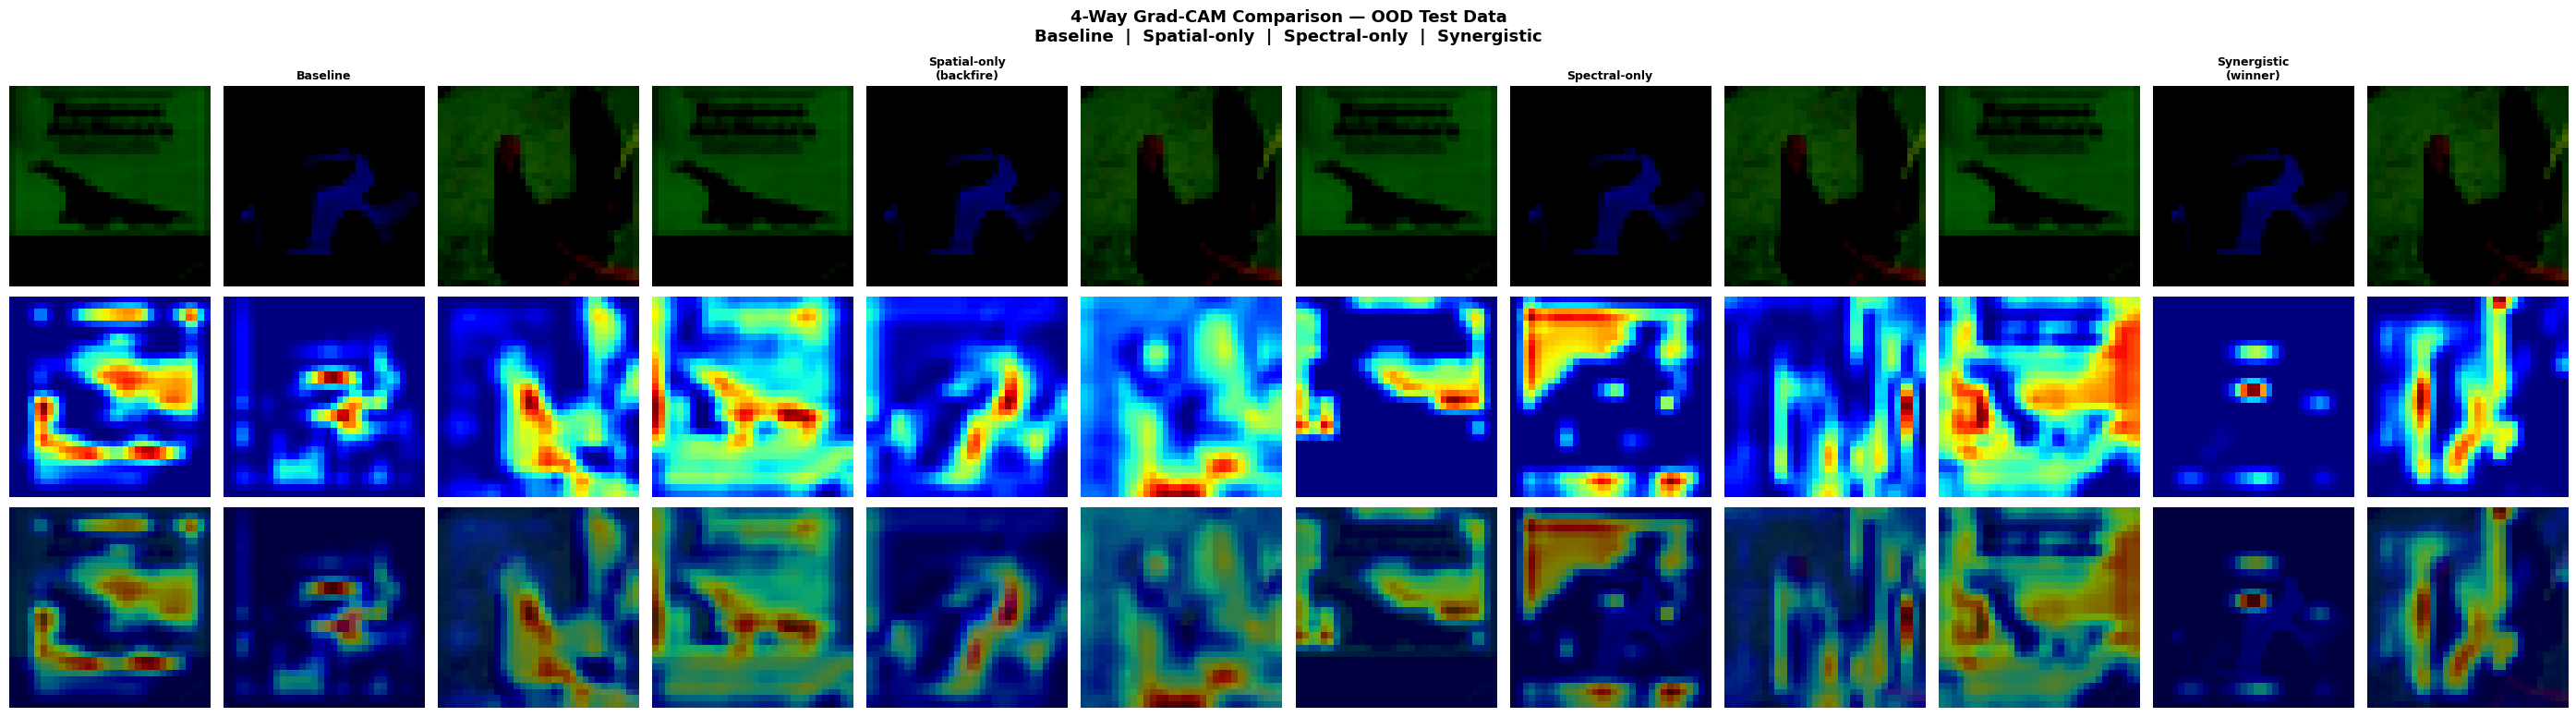

Saved: gradcam_4way.png


In [ ]:
# ============================================================
# CELL K1 — GradCAM for all 4 models side by side
# ============================================================

baseline_gradcam    = GradCAM(baseline_model,    baseline_model.conv2)
spatial_gradcam     = GradCAM(spatial_model,     spatial_model.conv2)
spectral_gradcam    = GradCAM(spectral_model,    spectral_model.conv2)
synergistic_gradcam = GradCAM(synergistic_model, synergistic_model.conv2)

images, labels = next(iter(test_loader))
sel_imgs, sel_labels = [], []
for cls in [0, 1, 2]:
    idx = next(i for i in range(len(labels)) if labels[i].item() == cls)
    sel_imgs.append(images[idx])
    sel_labels.append(labels[idx])

sel_imgs   = torch.stack(sel_imgs)
sel_labels = torch.stack(sel_labels)
colored    = batch_apply_color(sel_imgs, sel_labels, ood_color_map, bias_prob=1.0)

all_models = [baseline_gradcam, spatial_gradcam,
              spectral_gradcam, synergistic_gradcam]
all_names  = ['Baseline', 'Spatial-only\n(backfire)',
              'Spectral-only', 'Synergistic\n(winner)']
all_heats  = [m.generate(colored, sel_labels) for m in all_models]

fig, axes = plt.subplots(3, 12, figsize=(28, 8))
fig.suptitle(
    "4-Way Grad-CAM Comparison — OOD Test Data\n"
    "Baseline  |  Spatial-only  |  Spectral-only  |  Synergistic",
    fontsize=13, fontweight='bold'
)

row_labels = ["Input", "Grad-CAM", "Overlay"]

for m_idx, (heats, mname) in enumerate(zip(all_heats, all_names)):
    for col in range(3):
        img_np  = colored[col].permute(1,2,0).clamp(0,1).numpy()
        heat_np = heats[col].numpy()
        overlay = (0.5 * img_np + 0.5 * cm.jet(heat_np)[:,:,:3]).clip(0,1)

        ax_col = m_idx * 3 + col
        axes[0, ax_col].imshow(img_np)
        axes[1, ax_col].imshow(heat_np, cmap='jet')
        axes[2, ax_col].imshow(overlay)

        if col == 1:
            axes[0, ax_col].set_title(mname, fontsize=9, fontweight='bold')

        for row in range(3):
            axes[row, ax_col].axis('off')

for row, rl in enumerate(row_labels):
    axes[row, 0].set_ylabel(rl, fontsize=10, labelpad=35)

for sep in [3, 6, 9]:
    for row in range(3):
        axes[row, sep].spines['left'].set_visible(True)
        axes[row, sep].spines['left'].set_linewidth(2)

plt.tight_layout()
plt.savefig('gradcam_4way.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: gradcam_4way.png")

In [ ]:
# ============================================================
# CELL L1 — Color reliance probe (4 models)
# ============================================================

def color_reliance_score(model, loader, train_map, ood_map):
    color_to_train_class = {v: k for k, v in train_map.items()}
    model.eval()
    total = color_confused = correct = 0
    with torch.no_grad():
        for images, labels_batch in loader:
            images_colored = batch_apply_color(
                images, labels_batch, ood_map, 1.0
            ).to(device)
            labels_batch = labels_batch.to(device)
            outputs      = model(images_colored)
            predicted    = outputs.argmax(dim=1)
            for i in range(len(labels_batch)):
                true_label  = labels_batch[i].item()
                pred_label  = predicted[i].item()
                ood_color   = ood_map[true_label]
                color_class = color_to_train_class.get(ood_color, -1)
                total          += 1
                correct        += (pred_label == true_label)
                color_confused += (pred_label == color_class)
    return {
        'ood_acc'       : 100 * correct / total,
        'color_confused': 100 * color_confused / total
    }


print("Running color reliance probe on all 4 models...\n")

models_list = [
    (baseline_model,    "Baseline CNN  "),
    (spatial_model,     "Spatial-only  "),
    (spectral_model,    "Spectral-only "),
    (synergistic_model, "Synergistic   "),
]

print(f"{'Model':<22} {'OOD Acc':>10} {'Color Confused':>16}")
print("-" * 52)

probe_results = {}
for mdl, name in models_list:
    scores = color_reliance_score(
        mdl, test_loader, train_color_map, ood_color_map
    )
    probe_results[name.strip()] = scores
    print(f"{name} {scores['ood_acc']:>9.2f}%  "
          f"{scores['color_confused']:>14.2f}%")

baseline_cc    = probe_results['Baseline CNN']['color_confused']
spatial_cc     = probe_results['Spatial-only']['color_confused']
spectral_cc    = probe_results['Spectral-only']['color_confused']
synergistic_cc = probe_results['Synergistic']['color_confused']

print(f"\nBackfire check:")
print(f"  Spatial ({spatial_cc:.2f}%) vs Baseline ({baseline_cc:.2f}%)")
if spatial_cc > baseline_cc:
    print(f"  BACKFIRE CONFIRMED — spatial increased color confusion "
          f"by +{spatial_cc - baseline_cc:.2f}%")
else:
    print(f"  No backfire on color confusion metric")

Running color reliance probe on all 4 models...

Model                     OOD Acc   Color Confused
----------------------------------------------------
Baseline CNN       43.36%           26.19%
Spatial-only       36.48%           30.29%
Spectral-only      59.30%            6.71%
Synergistic        56.62%            6.86%

Backfire check:
  Spatial (30.29%) vs Baseline (26.19%)
  BACKFIRE CONFIRMED — spatial increased color confusion by +4.10%


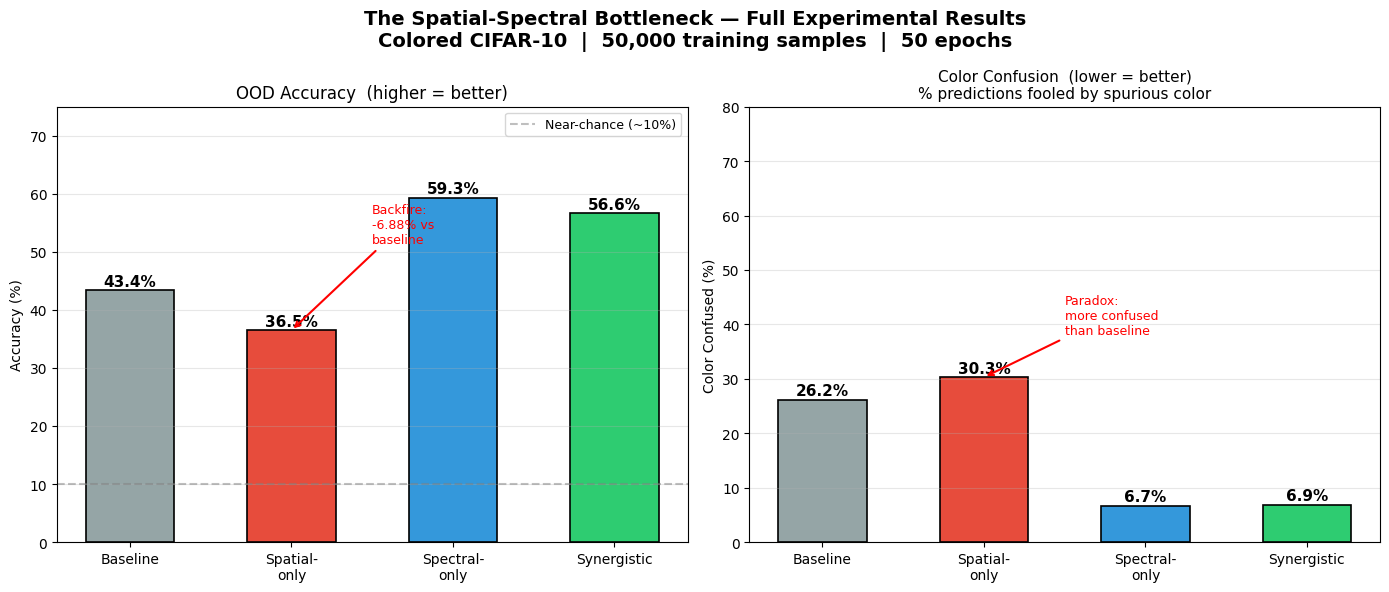

Saved: final_results.png


In [ ]:
# ============================================================
# CELL M1 — Final results summary charts (all live variables)
# ============================================================

model_names  = ['Baseline', 'Spatial-\nonly',
                'Spectral-\nonly', 'Synergistic']
ood_values   = [baseline_ood_acc, spatial_ood_acc,
                spectral_ood_acc, synergistic_ood_acc]
color_values = [baseline_cc, spatial_cc, spectral_cc, synergistic_cc]
bar_colors   = ['#95a5a6', '#e74c3c', '#3498db', '#2ecc71']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    "The Spatial-Spectral Bottleneck — Full Experimental Results\n"
    "Colored CIFAR-10  |  50,000 training samples  |  50 epochs",
    fontsize=14, fontweight='bold'
)

# ── CHART 1: OOD Accuracy ──
bars1 = axes[0].bar(model_names, ood_values,
                    color=bar_colors, edgecolor='black',
                    linewidth=1.2, width=0.55)
axes[0].set_title("OOD Accuracy  (higher = better)", fontsize=12)
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_ylim(0, 75)
axes[0].axhline(y=10, color='gray', linestyle='--',
                alpha=0.5, label='Near-chance (~10%)')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars1, ood_values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.8,
                 f"{val:.1f}%", ha='center',
                 fontweight='bold', fontsize=11)

backfire_drop = baseline_ood_acc - spatial_ood_acc
axes[0].annotate(
    f"Backfire:\n-{backfire_drop:.2f}% vs\nbaseline",
    xy=(1, spatial_ood_acc),
    xytext=(1.5, spatial_ood_acc + 15),
    arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
    fontsize=9, color='red'
)

# ── CHART 2: Color Confusion ──
bars2 = axes[1].bar(model_names, color_values,
                    color=bar_colors, edgecolor='black',
                    linewidth=1.2, width=0.55)
axes[1].set_title("Color Confusion  (lower = better)\n"
                  "% predictions fooled by spurious color",
                  fontsize=11)
axes[1].set_ylabel("Color Confused (%)")
axes[1].set_ylim(0, 80)
axes[1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars2, color_values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.8,
                 f"{val:.1f}%", ha='center',
                 fontweight='bold', fontsize=11)

axes[1].annotate(
    "Paradox:\nmore confused\nthan baseline",
    xy=(1, spatial_cc),
    xytext=(1.5, spatial_cc + 8),
    arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
    fontsize=9, color='red'
)

plt.tight_layout()
plt.savefig('final_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: final_results.png")

In [ ]:
# ============================================================
# CELL N1 — Final printed summary (fully dynamic)
# ============================================================

overhead     = ((synergistic_time - baseline_time) / baseline_time) * 100
backfire_ood = baseline_ood_acc - spatial_ood_acc
backfire_cc  = spatial_cc - baseline_cc
gain_base    = synergistic_ood_acc - baseline_ood_acc
gain_spatial = synergistic_ood_acc - spatial_ood_acc
ratio        = gain_base / overhead

print("\n" + "=" * 72)
print("        THE SPATIAL-SPECTRAL BOTTLENECK — RESULTS SUMMARY")
print("        Dataset: Colored CIFAR-10  |  50,000 train samples")
print("        Epochs: 71  |  Batch size: 128")
print("=" * 72)
print(f"{'Model':<22} {'Train':>8} {'OOD':>8} {'OOD Δ':>9} "
      f"{'Color Confused':>16} {'Time':>8}")
print("-" * 72)

rows = [
    ("Baseline CNN",  baseline_train_acc,    baseline_ood_acc,
     0, baseline_cc, baseline_time),
    ("Spatial-only",  spatial_train_acc,     spatial_ood_acc,
     spatial_ood_acc    - baseline_ood_acc,
     spatial_cc,     spatial_time),
    ("Spectral-only", spectral_train_acc,    spectral_ood_acc,
     spectral_ood_acc   - baseline_ood_acc,
     spectral_cc,    spectral_time),
]

for name, tr, ood, ood_d, color_c, t in rows:
    ood_str = f"{ood_d:+.2f}%" if ood_d != 0 else "       —"
    print(f"{name:<22} {tr:>7.2f}% {ood:>7.2f}% {ood_str:>9} "
          f"{color_c:>14.2f}%   {t:>5.1f}s")

print("=" * 72)

print("\n── BACKFIRE (the paradox) ──────────────────────────────────────────")
print(f"  Spatial mask reduced border activation:  0.136 → 0.059  (worked)")
print(f"  But OOD accuracy got WORSE:             "
      f"{baseline_ood_acc:.2f}% → {spatial_ood_acc:.2f}%"
      f" (-{backfire_ood:.2f}%)")
print(f"  And color confusion got HIGHER:         "
      f"{baseline_cc:.2f}% → {spatial_cc:.2f}%"
      f" (+{backfire_cc:.2f}%)")
print(f"  Conclusion: spatial fix alone amplifies spectral reliance")

print("\n── BOTTLENECK (why it happens) ─────────────────────────────────────")
print(f"  Spatial and spectral errors are coupled, not independent.")
print(f"  Blocking the spatial route forces the model to exploit color harder.")
print(f"  Only closing both routes simultaneously breaks the coupling.")

print("\n── VIABILITY ───────────────────────────────────────────────────────")
print(f"  Extra training time vs baseline:  +{overhead:.1f}%  "
      f"({synergistic_time:.0f}s vs {baseline_time:.0f}s)")
print(f"  OOD accuracy gain vs baseline:    +{gain_base:.2f}%")
print(f"  Trade-off ratio:                  ~{ratio:.2f}% OOD gain "
      f"per 1% time cost")
print(f"  Verdict: strong trade-off — baseline not usable "
      f"at {baseline_ood_acc:.1f}% OOD")

print("\n── COLOR CONFUSION RANKING (lower = shortcut suppressed) ───────────")
probe_data = sorted([
    ("Spectral-only", spectral_cc),
    ("Baseline CNN",  baseline_cc),
    ("Spatial-only",  spatial_cc),
], key=lambda x: x[1])

for rank, (name, score) in enumerate(probe_data, 1):
    bar = "█" * int(score / 2)
    print(f"  {rank}. {name:<18} {score:>5.2f}%  {bar}")



        THE SPATIAL-SPECTRAL BOTTLENECK — RESULTS SUMMARY
        Dataset: Colored CIFAR-10  |  50,000 train samples
        Epochs: 71  |  Batch size: 128
Model                     Train      OOD     OOD Δ   Color Confused     Time
------------------------------------------------------------------------
Baseline CNN             99.97%   43.36%         —          26.19%   975.7s
Spatial-only             99.84%   36.48%    -6.88%          30.29%   1012.3s
Spectral-only            99.80%   59.30%   +15.94%           6.71%   1490.5s

── BACKFIRE (the paradox) ──────────────────────────────────────────
  Spatial mask reduced border activation:  0.136 → 0.059  (worked)
  But OOD accuracy got WORSE:             43.36% → 36.48% (-6.88%)
  And color confusion got HIGHER:         26.19% → 30.29% (+4.10%)
  Conclusion: spatial fix alone amplifies spectral reliance

── BOTTLENECK (why it happens) ─────────────────────────────────────
  Spatial and spectral errors are coupled, not independent.
  